# Обучение классификатора отзывов

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Подготовка датасета

In [ ]:
import os
os.chdir('/content/drive/MyDrive/')

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("geo-reviews-dataset-2023.csv")
df.head()

,address,name_ru,rating,rubrics,text
0,"Екатеринбург, ул. Московская / ул. Волгоградск...",Московский квартал,3.0,Жилой комплекс,Московский квартал 2.\nШумно : летом по ночам ...
1,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
2,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я..."
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...
4,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...


In [ ]:
df.rating.value_counts()

,count
rating,
5.0,390515
4.0,41160
1.0,34351
3.0,21686
2.0,12088
0.0,200


#### Стратегия подготовки данных для бинарной классификации отзывов:

Для решения задачи автоматического обнаружения критических отзывов мы применяем следующую логику трансформации исходных данных:


Мы преобразуем числовые рейтинги в бинарные метки согласно бизнес-целям:
- **Негативный** ( **класс 1** ) - если рейтинг ≤ 2.   
*Бизнес смысл*: это критические отзывы, требующие **немедленной реакции** поддержки или менеджмента. Модель обучается приоритетно искать именно этот класс.
  
- **Позитивный** ( **Класс 0** ) - если рейтинг ≥ 4.   
*Бизнес смысл*: это успешный опыт клиента. Эти отзывы не требуют срочного вмешательства и служат фоновым классом («нормой») для обучения.


Отзывы с рейтингом **3** полностью удаляются из датасета перед обучением.\
**Обоснование:** Нейтральные оценки часто неоднозначны по тональности. Их наличие может «размыть» границу принятия решений моделью, снизив её способность четко различать полярные случаи (явно плохо vs явно хорошо).



In [ ]:
df_prepared = df[(df['rating'] <= 2) | (df['rating'] >= 4)].copy()

# Дедупликация по тексту отзыва
df_prepared = df_prepared.drop_duplicates(subset=['text'], keep='first').copy()

# Создание целевой переменной (label)
# 1 — негативный отзыв (рейтинг <= 2)
# 0 — позитивный отзыв (рейтинг >= 4)
df_prepared['label'] = (df_prepared['rating'] <= 2).astype(int)

# Сброс индекса
df_prepared = df_prepared.reset_index(drop=True)

In [ ]:
df_prepared

,address,name_ru,rating,rubrics,text,label
0,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ...",0
1,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я...",1
2,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...,0
3,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...,0
4,"Иркутская область, Черемхово, Первомайская ули...",Tele2,5.0,Оператор сотовой связи;Интернет-провайдер,"Приятное общение, все доступно объяснили, мне ...",0
...,...,...,...,...,...,...
478194,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,"Охрана кривая но добрая, двери не закрываются ...",0
478195,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,По сравнению со многими современными платформа...,0
478196,"Новосибирск, Коммунистическая улица, 48А",NaN,5.0,"Бар, паб","Приятная атмосфера, прекрасное вино, волшебная...",0
478197,"Астраханская область, Харабалинский район",Сарай-Бату,5.0,Достопримечательность,Был с семьёй 13.06.23 Отличное место. Рекоменд...,0


In [ ]:
df_prepared.label.value_counts()

,count
label,
0,431560
1,46639


Разделяем датасет на train, validation и test:
- Под train 70%
- Под val 10%
- Под test 20%

In [ ]:
from sklearn.model_selection import train_test_split

# Отделяем тестовую выборку (20% от всего датасета)
# stratify по label сохраняет пропорцию классов (0 и 1)
df_train_val, df_test = train_test_split(
    df_prepared,
    test_size=0.2,           # 20% на тест
    random_state=42,
    stratify=df_prepared['label'],
)

# Разделяем оставшиеся 80% на train (70%) и validation (10%)
# 10% / 80% = 0.125 (12.5% от оставшихся данных пойдут на валидацию)
df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.125,         # 12.5% от 80% = 10% от общего датасета
    random_state=42,
    stratify=df_train_val['label'],
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [ ]:
print(f"\nОбщий размер: {len(df_prepared)} отзывов")
print(f"\nРазмеры выборок:")
print(f"  Train:      {len(df_train)} ({len(df_train)/len(df_prepared)*100:.1f}%)")
print(f"  Validation: {len(df_val)}   ({len(df_val)/len(df_prepared)*100:.1f}%)")
print(f"  Test:       {len(df_test)}  ({len(df_test)/len(df_prepared)*100:.1f}%)")

print(f"\nРаспределение классов на train:")
print(df_train['label'].value_counts(normalize=True).sort_index())


Общий размер: 478199 отзывов

Размеры выборок:
  Train:      334739 (70.0%)
  Validation: 47820   (10.0%)
  Test:       95640  (20.0%)

Распределение классов на train:
label
0    0.90247
1    0.09753
Name: proportion, dtype: float64


## Обучение модели

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
from tqdm.auto import tqdm
import os
import random
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

### Основные параметры модели:

Модель для тюнинга - https://huggingface.co/intfloat/multilingual-e5-small

In [ ]:
MODEL_NAME = 'intfloat/multilingual-e5-small'
BATCH_SIZE = 256
MAX_LENGTH = 64
NUM_EPOCHS = 10
RANDOM_SEED = 42

In [ ]:
def seed_all(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(RANDOM_SEED)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

In [ ]:
text = "Всем привет с вами блогер меллстрой и мы сегодня будем играть карту"
encoding = tokenizer(
    text,
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH,
    return_tensors='pt'
)
print(encoding)

{'input_ids': tensor([[     0,   7762,    130, 146038,    135,  49090, 207704,  92084,    547,
          27880,     35,   2176,  23294,  61041,  56116, 128922,      2,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])}


In [ ]:
from termcolor import colored

tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
attention_mask = encoding['attention_mask'][0]
input_ids = encoding['input_ids'][0].tolist()

# Собираем только полезные токены (без PAD)
real_tokens = [t for t, m in zip(tokens, attention_mask) if m == 1]
real_ids = [id_ for id_, m in zip(input_ids, attention_mask) if m == 1]

# Цвета для чередования
colors = ['red', 'green', 'yellow', 'blue', 'magenta', 'cyan', 'white']

# Заголовок с номерами токенов
print("\n№ токена:  ", end='')
for i in range(len(real_tokens)):
    print(colored(f'{i:^7}', 'white'), end='')
print()

# Разделитель
print("           " + "─"*7 * len(real_tokens))

# Строка с токенами
print("Токены:    ", end='')
for i, token in enumerate(real_tokens):
    color = colors[i % len(colors)]
    display = token.replace('▁', '_')
    print(colored(f'{display:^7}', color), end='')
print()

# Строка с ID токенов
print("ID:        ", end='')
for i, token_id in enumerate(real_ids):
    color = colors[i % len(colors)]
    print(colored(f'{token_id:^7}', color), end='')
print()



№ токена:     0      1      2      3      4      5      6      7      8      9     10     11     12     13     14     15     16   
           ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Токены:      <s>   _Все     м   _привет  _с    _вами _блогер _мел     л    строй   _и     _мы  _сегодня_будем _играть_карту  </s>  
ID:           0    7762    130  146038   135   49090 207704  92084   547   27880   35    2176   23294  61041  56116 128922    2   


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")

text = "Всем привет с вами блогер меллстрой и мы сегодня будем играть карту"
encoding = tokenizer(
    text,
    truncation=True,
    padding='max_length',
    max_length=MAX_LENGTH,
    return_tensors='pt'
)

tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
attention_mask = encoding['attention_mask'][0]
input_ids = encoding['input_ids'][0].tolist()

# Собираем только полезные токены (без PAD)
real_tokens = [t for t, m in zip(tokens, attention_mask) if m == 1]
real_ids = [id_ for id_, m in zip(input_ids, attention_mask) if m == 1]

# Цвета для чередования
colors = ['red', 'green', 'yellow', 'blue', 'magenta', 'cyan', 'white']

# Заголовок с номерами токенов
print("\n№ токена:  ", end='')
for i in range(len(real_tokens)):
    print(colored(f'{i:^7}', 'white'), end='')
print()

# Разделитель
print("           " + "─"*7 * len(real_tokens))

# Строка с токенами
print("Токены:    ", end='')
for i, token in enumerate(real_tokens):
    color = colors[i % len(colors)]
    display = token.replace('▁', '_')
    print(colored(f'{display:^7}', color), end='')
print()

# Строка с ID токенов
print("ID:        ", end='')
for i, token_id in enumerate(real_ids):
    color = colors[i % len(colors)]
    print(colored(f'{token_id:^7}', color), end='')
print()


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


№ токена:     0      1      2      3      4      5      6      7      8      9     10     11     12     13     14     15     16   
           ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Токены:     [CLS]  Всем  привет    с    вами  блогер   мел   ##лс   ##тр   ##ой     и     мы   сегодня будем играть  карту  [SEP] 
ID:          101   15393  26856   869   60503  69235  11304  38072  16799  1519    851   8235   12904  28050  15726  32956   102  


In [ ]:
class TextDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=64):
        self.texts = df.text.tolist()
        self.labels = df.label.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.float)
        }

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME) # берем e5

train_dataset = TextDataset(
    df_train,
    tokenizer,
    MAX_LENGTH
)

val_dataset = TextDataset(
    df_val,
    tokenizer,
    MAX_LENGTH
)

test_dataset = TextDataset(
    df_test,
    tokenizer,
    MAX_LENGTH
)

In [ ]:
train_dataset[100]

{'input_ids': tensor([     0,   3858,    546,  47981,  21246,    135, 180443,    130, 214456,
            419,     35,     49,  20765,    546,  63781,  43525,    419,      5,
           2443,  12959,   8007,  91830,    695,  48223,      4,  12868,   3549,
            414,  65718,     35,   1203,   1097,    129, 158534,    130,  21013,
            130,     38,      2,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1,      1,      1,      1,      1,      1,      1,      1,      1,
              1]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'label': tensor(0.)}

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
batch = next(iter(train_loader))
batch

{'input_ids': tensor([[     0,   1721,  26958,  ...,  36562, 146038,      2],
         [     0, 212309,   2192,  ...,  41661,   9977,      2],
         [     0,   7762, 213683,  ...,      1,      1,      1],
         ...,
         [     0,   5188, 121760,  ...,      1,      1,      1],
         [     0,   3858,    546,  ...,      1,      1,      1],
         [     0,  61421,     89,  ...,      1,      1,      1]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]]),
 'label': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
    

In [ ]:
batch["input_ids"].shape

torch.Size([256, 64])

In [ ]:
batch["attention_mask"].shape

torch.Size([256, 64])

In [ ]:
batch["label"].shape

torch.Size([256])

Число спусков на 1 эпоху

In [ ]:
len(train_loader)

1308

### Выбираем модель для fine tuning

In [ ]:
# Модель для классификации в случае если есть CLS токен
class BERT_Model(nn.Module):
    def __init__(self, model_name='DeepPavlov/rubert-base-cased'):
        super(BERT_Model, self).__init__()
        self.e5 = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Linear(self.e5.config.hidden_size, 1) # бинарная классификация

    def forward(self, input_ids, attention_mask):
        outputs = self.e5(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]  # Берем embedding первого токена [CLS - <s>]
        logits = self.classifier(pooled_output)
        return logits.squeeze(-1)

У модели intfloat/multilingual-e5-small нет CLS токена. Первый токен `<s>` не обучен представлять всю последовательность, поэтому нужно усреднять эмбеддинги всех токенов (кроме padding)

In [ ]:
class E5Classifier(nn.Module):
    def __init__(self, model_name='intfloat/multilingual-e5-small'):
        super().__init__()
        self.model = AutoModel.from_pretrained(model_name)
        print("embed_dim = ", self.model.config.hidden_size)
        self.classifier = nn.Linear(self.model.config.hidden_size, 1) # бинарная классификация

    def mean_pooling(self, token_embeddings, attention_mask):
        """Усреднение векторов всех токенов кроме padding"""
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(
            token_embeddings.size()
        ).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        return sum_embeddings / sum_mask

    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)

        # Average pooling
        pooled_output = self.mean_pooling(
            outputs.last_hidden_state,
            attention_mask
        )

        logits = self.classifier(pooled_output)
        return logits.squeeze(-1)

In [ ]:
model = E5Classifier(model_name=MODEL_NAME)

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

embed_dim =  384


In [ ]:
model

E5Classifier(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(250037, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_af

In [ ]:
# Функция для вычисления числа параметров
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

count_parameters(model)

(117654145, 117654145)

In [ ]:
# Функция для вычисления метрик
def compute_metrics(predictions, labels, threshold=0.5):
    predictions_binary = (predictions > threshold).astype(int)
    accuracy = accuracy_score(labels, predictions_binary)
    f1 = f1_score(labels, predictions_binary)
    precision = precision_score(labels, predictions_binary)
    recall = recall_score(labels, predictions_binary)
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0, reduction: str = "mean"):
        """
        Focal Loss для бинарной классификации.

        Parameters
        ----------
        alpha : torch.Tensor
            Веса классов размером [2] для [класс_0, класс_1].
            Пример: torch.tensor([0.75, 0.25])
        gamma : float
            Параметр фокусировки. По умолчанию 2.0.
        reduction : str
            'mean', 'sum' или 'none'.
        """
        super().__init__()
        # Гарантируем, что alpha — это тензор с плавающей точкой
        self.alpha = alpha.float()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        inputs : torch.Tensor
            Логиты модели (без сигмоиды), форма [Batch, ...]
        targets : torch.Tensor
            Метки классов (0 или 1), форма [Batch, ...]
        """
        assert inputs.shape == targets.shape, f"Shape mismatch: {inputs.shape} vs {targets.shape}"

        # Приводим targets к long для gather и float для BCE
        targets_long = targets.long()
        targets_float = targets.float()

        # 1. Бинарная кросс-энтропия без редукции
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets_float, reduction="none"
        )

        # 2. Вероятность правильного класса (p_t)
        p_t = torch.exp(-bce_loss)

        # 3. Выбор веса alpha для каждого пикселя/элемента
        # Перемещаем alpha на то же устройство, что и данные
        alpha = self.alpha.to(inputs.device)

        # gather выбирает вес: если target=0 -> alpha[0], если target=1 -> alpha[1]
        alpha_t = alpha.gather(0, targets_long.view(-1)).view_as(targets)

        # 4. Фокусирующий коэффициент (1 - p_t)^gamma
        focal_weight = (1 - p_t) ** self.gamma

        # 5. Итоговый лосс
        loss = alpha_t * focal_weight * bce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

In [ ]:
def train_model(model, train_loader, val_loader, device, num_epochs=5):
    model.to(device)

    # Инициализация оптимизатора, функции потерь и планировщика
    # Расчет параметров
    total_steps = len(train_loader) * num_epochs
    warmup_steps = int(0.05 * total_steps)  # 5% warmup

    loss_func = FocalLoss(
        alpha=torch.tensor([0.5, 1.0]),
        gamma=2.5
    )

    optimizer = AdamW(
        model.parameters(),
        lr=3e-5,
        weight_decay=0.01
    )

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # Списки для сохранения истории лоссов (для построения графиков)
    train_losses = []
    val_losses = []

    best_val_f1 = 0

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')

        # --- TRAIN ---
        model.train()
        total_train_loss = 0

        for batch in tqdm(train_loader, desc=f'Training', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = loss_func(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_train_loss += loss.item()

        train_losses.append(total_train_loss / len(train_loader))

        # --- VALIDATION ---
        model.eval()
        total_val_loss = 0
        val_predictions = []
        val_labels = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'Validation', leave=False):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)

                outputs = model(input_ids, attention_mask)

                # Считаем лосс валидации для графика
                loss = loss_func(outputs, labels)
                total_val_loss += loss.item()

                # Предсказания нужны только для расчета F1 (отбор лучшей модели)
                predictions = torch.sigmoid(outputs).cpu().numpy()
                val_predictions.extend(predictions)
                val_labels.extend(labels.cpu().numpy())

        val_losses.append(total_val_loss / len(val_loader))

        # Расчет метрик только для условия сохранения
        val_metrics = compute_metrics(np.array(val_predictions), np.array(val_labels))
        current_f1 = val_metrics['f1']
        val_acc = val_metrics['accuracy']

        print(f'Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val accuracy: {val_acc:.3f} | Val F1: {current_f1:.3f}')

        if current_f1 > best_val_f1:
            best_val_f1 = current_f1
            torch.save(model.state_dict(), 'best_model.pth')
            print("Model weights updated due to improved validation F1 score")

    print(f'\nTraining Complete. Best validation F1: {best_val_f1:.4f}')

    # Возвращаем модель и историю лоссов
    return model, train_losses, val_losses

In [34]:
# Запуск обучения
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

final_model, train_l, val_l = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
)


Epoch 1/10


Training:   0%|          | 0/1308 [00:00<?, ?it/s]

Validation:   0%|          | 0/187 [00:00<?, ?it/s]

Train Loss: 0.0171 | Val Loss: 0.0120 | Val accuracy: 0.970 | Val F1: 0.852
Model weights updated due to improved validation F1 score

Epoch 2/10


Training:   0%|          | 0/1308 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/187 [00:00<?, ?it/s]

Train Loss: 0.0033 | Val Loss: 0.0189 | Val accuracy: 0.972 | Val F1: 0.856

Epoch 10/10


Training:   0%|          | 0/1308 [00:00<?, ?it/s]

Validation:   0%|          | 0/187 [00:00<?, ?it/s]

Train Loss: 0.0029 | Val Loss: 0.0200 | Val accuracy: 0.972 | Val F1: 0.858

Training Complete. Best validation F1: 0.8663


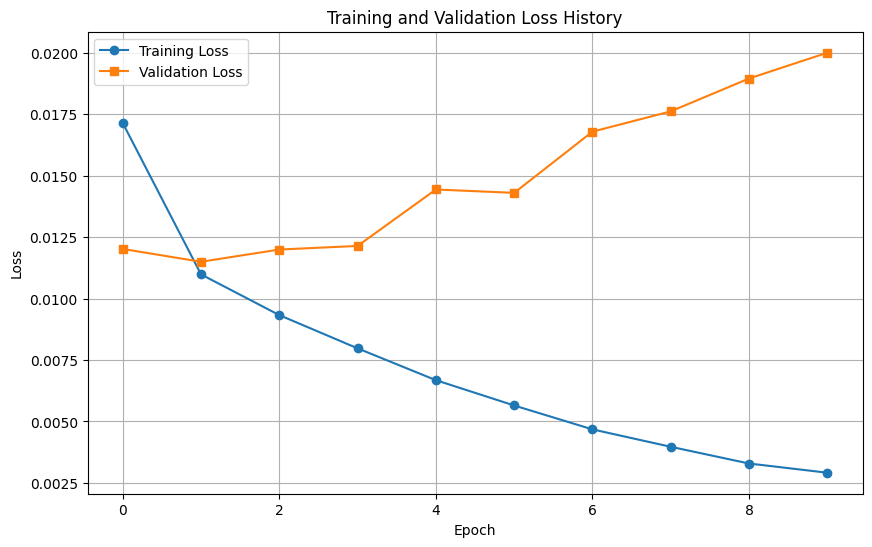

In [35]:
# Построение графика лосса от эпох
plt.figure(figsize=(10, 6))
plt.plot(train_l, label='Training Loss', marker='o')
plt.plot(val_l, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss History')
plt.legend()
plt.grid(True)
plt.show()

### Оценим качество на тесте

In [36]:
# Загружаем лучшую модель для финального тестирования
model.load_state_dict(torch.load('best_model.pth', map_location=device))

model.to(device).eval()

final_predictions = []
final_labels = []

# Сбор предсказаний на тестовом наборе
with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask)
        predictions = torch.sigmoid(outputs).cpu().numpy()

        final_predictions.extend(predictions)
        final_labels.extend(labels.cpu().numpy())

# Конвертация в массивы
final_predictions = np.array(final_predictions).ravel()  # Важно: flatten для бинарной задачи
final_labels = np.array(final_labels).ravel()

  0%|          | 0/374 [00:00<?, ?it/s]

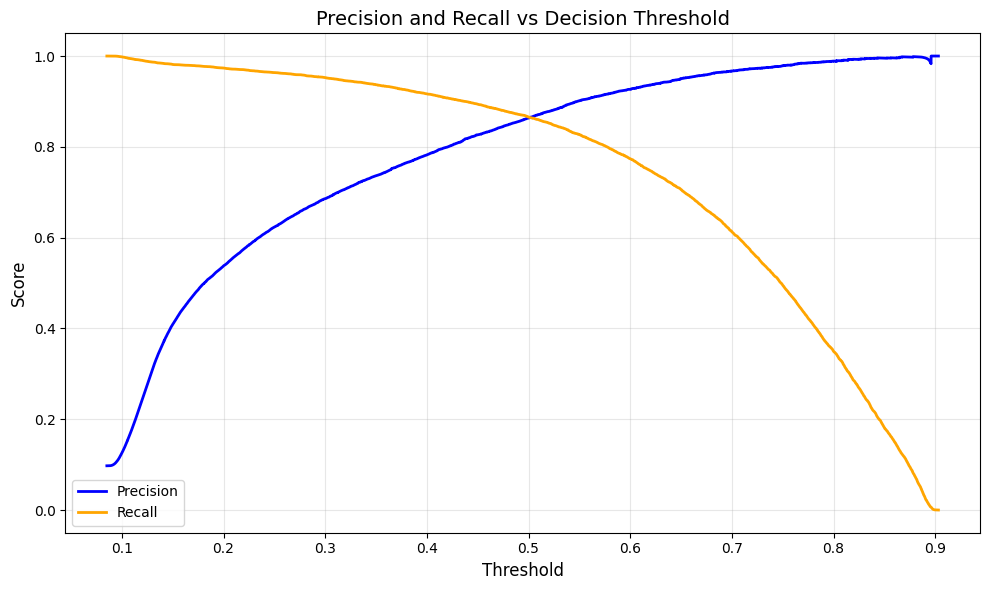

In [37]:
# Расчет метрик для разных порогов
precisions, recalls, thresholds = precision_recall_curve(final_labels, final_predictions)

# Построение графика зависимости от порога
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', linewidth=2, color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', linewidth=2, color='orange')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision and Recall vs Decision Threshold', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


CLASSIFICATION REPORT (threshold=0.5)
              precision    recall  f1-score   support

         0.0     0.9855    0.9852    0.9853     86312
         1.0     0.8636    0.8655    0.8645      9328

    accuracy                         0.9735     95640
   macro avg     0.9245    0.9253    0.9249     95640
weighted avg     0.9736    0.9735    0.9736     95640


CONFUSION MATRIX (threshold=0.5)


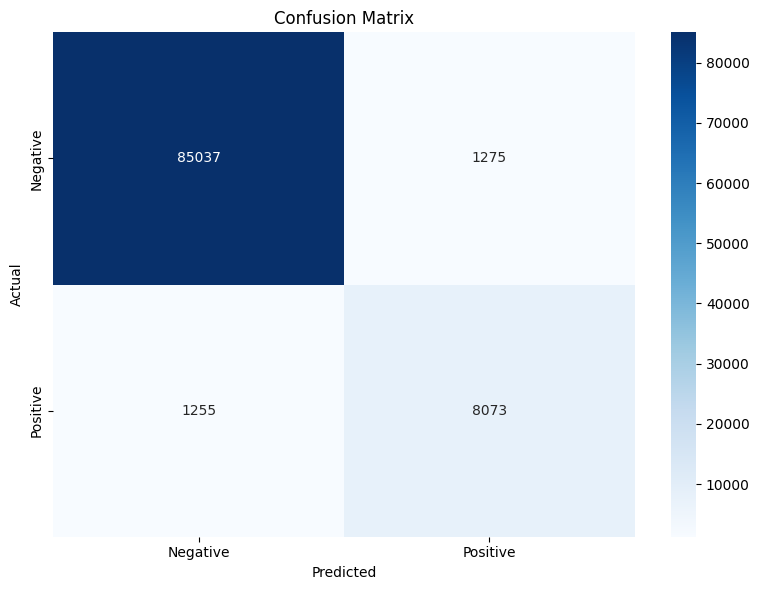

In [38]:
# Бинаризация предсказаний для основных метрик
threshold = 0.5
final_predictions_binary = (final_predictions > threshold).astype(int)

# --- Classification Report ---
print('\n' + '='*50)
print(f'CLASSIFICATION REPORT (threshold={threshold})')
print('='*50)
print(classification_report(final_labels, final_predictions_binary, digits=4))

# --- Confusion Matrix ---
print('\n' + '='*50)
print(f'CONFUSION MATRIX (threshold={threshold})')
print('='*50)
cm = confusion_matrix(final_labels, final_predictions_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Отсмотрим ошибки FP FN

In [43]:
# Добавляем столбцы в датафрейм
df_test['model_score'] = final_predictions
df_test['predicted_label'] = (final_predictions > 0.5).astype(int)

# Выводим примеры FP (ложные срабатывания)
fp_df = df_test[(df_test['predicted_label'] == 1) & (df_test['label'] == 0)]
print(f"\nFalse Positives (FP): {len(fp_df)}")
print("="*80)
for idx, row in fp_df.sample(min(5, len(fp_df))).iterrows():
    print(f"СКОР от модели: {row['model_score']:.4f}")
    print(f"Rating на сайте: {row['rating']:.4f}")
    print(f"ТЕКСТ: {row['text'][:200]}...")
    print("-"*80)


False Positives (FP): 1275
СКОР от модели: 0.5278
Rating на сайте: 4.0000
ТЕКСТ: Один раз побывать можно, постройки стилизованные под старину и тп, на этом все.
...
--------------------------------------------------------------------------------
СКОР от модели: 0.5445
Rating на сайте: 4.0000
ТЕКСТ: Парковка перед сервисом маленькая, с большим наклоном и заезд на территорию неудобный.
...
--------------------------------------------------------------------------------
СКОР от модели: 0.6639
Rating на сайте: 5.0000
ТЕКСТ: Здравствуйте. Посетил сегодня этот магазин.\nМагазин хороший не спорю. Но одно но:\nВ 9 утра подхожу к кассам, а ни одна не работает, говорят самообслуживания свободно это как понимать, а если у меня ...
--------------------------------------------------------------------------------
СКОР от модели: 0.6369
Rating на сайте: 4.0000
ТЕКСТ: Пляж завален большими камнями, их называют валуны. Пол пляжа не возможно использовать. Очень тесно из за этого. Люди лежат очень близк

In [44]:
# Выводим примеры FN (пропущенные цели)
fn_df = df_test[(df_test['predicted_label'] == 0) & (df_test['label'] == 1)]
print(f"\nFalse Negatives (FN): {len(fn_df)}")
print("="*80)
for idx, row in fn_df.sample(min(5, len(fn_df))).iterrows():
    print(f"СКОР от модели: {row['model_score']:.4f}")
    print(f"Rating на сайте: {row['rating']:.4f}")
    print(f"ТЕКСТ: {row['text'][:200]}...")
    print("-"*80)


False Negatives (FN): 1255
СКОР от модели: 0.4535
Rating на сайте: 2.0000
ТЕКСТ: Блюда вкусные. Респект повару. Но все впечатление портит обслуживание. Медленная подача, при небольшой посадке в зале. Вопрос "почему так долго?", Видимо очень задел официантку , на что был дан ответ,...
--------------------------------------------------------------------------------
СКОР от модели: 0.3943
Rating на сайте: 2.0000
ТЕКСТ: Люди долго ждут оформления и сдачу груза.Но буду честен не всегда бывает грустно раз в три неделе одна бывает более чем ,но так если под итожить на 3 балла с минусом .
...
--------------------------------------------------------------------------------
СКОР от модели: 0.3973
Rating на сайте: 1.0000
ТЕКСТ: Хорошее кафе, было. Всегда заходили выпить кофе и перекусить. В последнее время, кроме кофе ничего нет. Со сменой бариста всё изменилось. Очень жаль! Меняйтесь в лучшую сторону, верим в Вас! 
...
----------------------------------------------------------------------------

Визуализация распределения скоров у ошибок

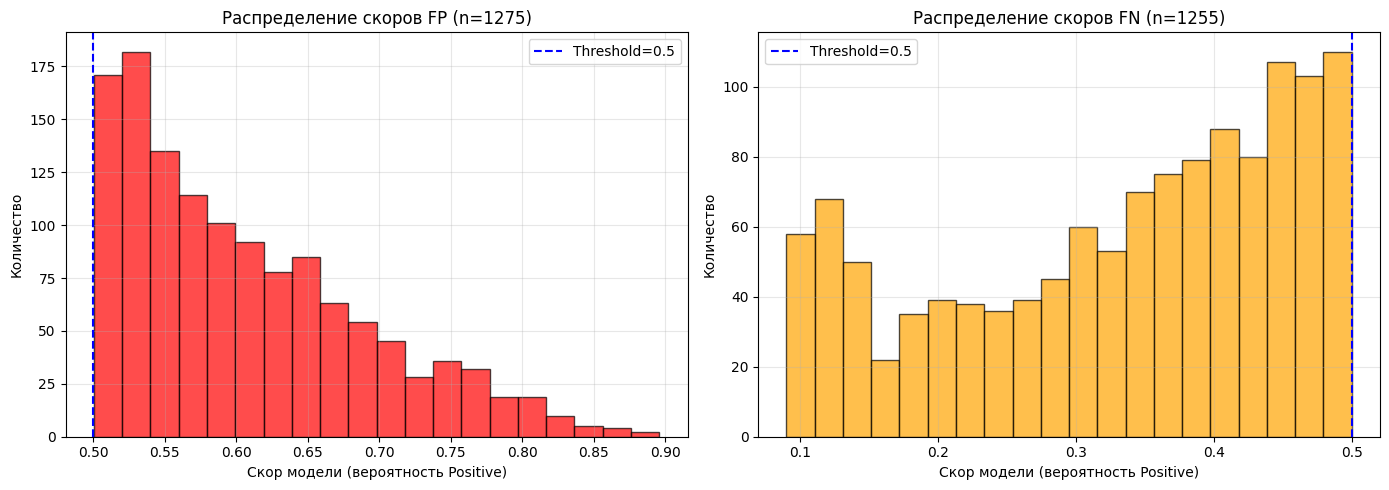

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение для FP
if len(fp_df) > 0:
    axes[0].hist(fp_df['model_score'], bins=20, alpha=0.7, color='red', edgecolor='black')
    axes[0].axvline(x=0.5, color='blue', linestyle='--', label='Threshold=0.5')
    axes[0].set_xlabel('Скор модели (вероятность Positive)')
    axes[0].set_ylabel('Количество')
    axes[0].set_title(f'Распределение скоров FP (n={len(fp_df)})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)


# Распределение для FN
if len(fn_df) > 0:
    axes[1].hist(fn_df['model_score'], bins=20, alpha=0.7, color='orange', edgecolor='black')
    axes[1].axvline(x=0.5, color='blue', linestyle='--', label='Threshold=0.5')
    axes[1].set_xlabel('Скор модели (вероятность Positive)')
    axes[1].set_ylabel('Количество')
    axes[1].set_title(f'Распределение скоров FN (n={len(fn_df)})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Отсмотрим скорее всего ошибки датасета по принцпу высокой уверенности модели в противоположном ответе

In [46]:
# Добавляем столбцы в датафрейм
df_test['model_score'] = final_predictions
df_test['predicted_label'] = (final_predictions > 0.5).astype(int)

# Выводим примеры FP (ложные срабатывания)
fp_df = df_test[(df_test['predicted_label'] == 1) & (df_test['label'] == 0) & (df_test['model_score'] > 0.875)]
print(f"\nFalse Positives (FP): {len(fp_df)}")
print("="*80)
for idx, row in fp_df.sample(min(3, len(fp_df))).iterrows():
    print(f"СКОР от модели: {row['model_score']:.4f}")
    print(f"Rating на сайте: {row['rating']:.4f}")
    print(f"ТЕКСТ: {row['text'][:200]}...")
    print("-"*80)


False Positives (FP): 2
СКОР от модели: 0.8959
Rating на сайте: 5.0000
ТЕКСТ: Ужасное обслуживание в данном магазине(((Продавцы не умеют пользоваться кассовым аппаратом,не знают куда нажать для оплаты по Q коду,потом у них не выходит чек и они не отдают продукты,предлагая оплат...
--------------------------------------------------------------------------------
СКОР от модели: 0.8782
Rating на сайте: 5.0000
ТЕКСТ: Отвратительное обслуживание, при очереди в 20 человек, второй кассир уходит читать намаз, цены на полках не соответствуют ценам на кассе, бардак, хамство, говорят, а все равно мы здесь не надолго, ужа...
--------------------------------------------------------------------------------


In [47]:
# Выводим примеры FN (пропущенные цели)
fn_df = df_test[(df_test['predicted_label'] == 0) & (df_test['label'] == 1) & (df_test['model_score'] < 0.125)]
print(f"\nFalse Negatives (FN): {len(fn_df)}")
print("="*80)
for idx, row in fn_df.sample(min(3, len(fn_df))).iterrows():
    print(f"СКОР от модели: {row['model_score']:.4f}")
    print(f"Rating на сайте: {row['rating']:.4f}")
    print(f"ТЕКСТ: {row['text'][:200]}...")
    print("-"*80)


False Negatives (FN): 109
СКОР от модели: 0.0931
Rating на сайте: 1.0000
ТЕКСТ: Заказывали окно на веранду, всё сделали в срок, очень вежливый и отзывчивый менеджер Алмаз, всём довольны, спасибо! 
...
--------------------------------------------------------------------------------
СКОР от модели: 0.1133
Rating на сайте: 2.0000
ТЕКСТ: Спокойная, уютная атмосфера, приветливая девушка за прилавком. Предложила кофе с собой, помогла с выбором. Взяли круассаны, карамельный чизкейк и медовик. \nОдин круассан вкусный, мягкий. Пирожные дуб...
--------------------------------------------------------------------------------
СКОР от модели: 0.1118
Rating на сайте: 0.0000
ТЕКСТ: Вкусно, сытно и если б не популярность, то были б очереди поменьше )))
...
--------------------------------------------------------------------------------


---

## Оценка качества на своих примерах

In [49]:
# Функция для предсказания на новых данных
def predict_texts(model, tokenizer, texts, device):
    model.eval()
    predictions = []

    for text in texts:
        encoding = tokenizer(
            str(text),
            truncation=True,
            padding='max_length',
            max_length=MAX_LENGTH,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            output = model(input_ids, attention_mask)
            prob = torch.sigmoid(output).cpu().item()
            predictions.append(prob)

    return predictions

In [61]:
test_texts = [
    "Отличее место, бывал пару раз, теперь родственникам рекоммендую",
    "Место отвратительное. Никому сюда не рекомендую ходить! Даже под дулом пистолета!",
    "Лучшее место, которое я посещал!!!!!!!!!!!",
    "Какое хорошее место! Запомнилось, теперь всегда хожу туда",
    "Да норм в общем тут все, да!",
    "Не, ходите туда!",
    "Не ходите туда!"
]
predict_texts(model=model, tokenizer=tokenizer, texts=test_texts, device=device)

[0.1247939020395279,
 0.8820666074752808,
 0.12666048109531403,
 0.1157703846693039,
 0.19233167171478271,
 0.530103325843811,
 0.7255285978317261]

### lime интерпретация модели

In [63]:
pip install lime onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 13.3 MB/s eta 0:00:00


Probabilities: Neg=0.118, Pos=0.882
Predicted: Negative


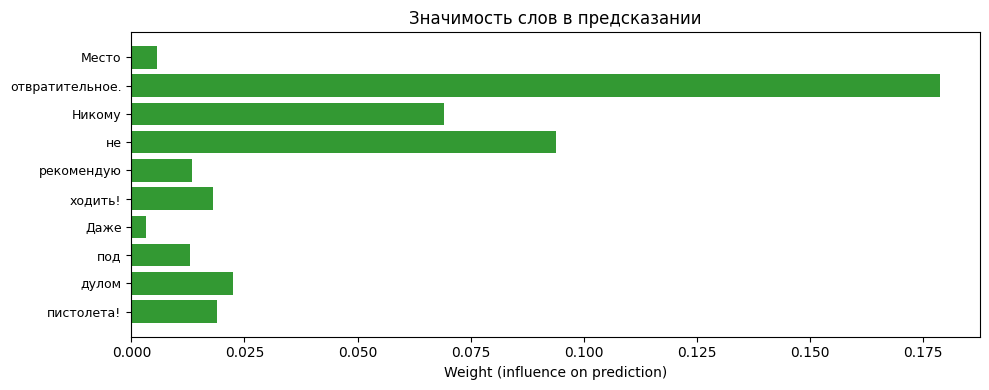

In [58]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from lime.lime_text import LimeTextExplainer

def create_lime_predictor(model, tokenizer, device, max_length=512):
    model.eval()
    def predictor(texts):
        probs = []
        with torch.no_grad():
            for text in texts:
                enc = tokenizer(str(text), truncation=True, padding='max_length',
                               max_length=max_length, return_tensors='pt')
                input_ids = enc['input_ids'].to(device)
                attention_mask = enc['attention_mask'].to(device)
                output = model(input_ids, attention_mask)
                prob_1 = torch.sigmoid(output).cpu().item()
                probs.append([1-prob_1, prob_1])
        return np.array(probs)
    return predictor

def plot_lime_explanation_original_order(explanation, text, top_n=10, figsize=(10, 4)):
    """Визуализация в порядке исходного текста"""
    # Получаем все слова с весами
    lime_dict = {word: weight for word, weight in explanation.as_list()}

    # Разбиваем исходный текст на слова (в оригинальном порядке)
    words_in_order = text.split()

    # Берём только те слова, для которых есть веса от LIME
    words = []
    weights = []
    for word in words_in_order:
        # Очищаем слово от знаков препинания для поиска
        clean_word = word.strip('.,!?;:')
        if clean_word in lime_dict and len(words) < top_n:
            words.append(word)
            weights.append(lime_dict[clean_word])

    colors = ['green' if w > 0 else 'red' for w in weights]

    plt.figure(figsize=figsize)
    plt.barh(range(len(words)), weights, color=colors, alpha=0.8)
    plt.yticks(range(len(words)), words, fontsize=9)
    plt.xlabel('Weight (influence on prediction)')
    plt.title(f'Значимость слов в предсказании')
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# --- Использование ---
predict_fn = create_lime_predictor(model, tokenizer, device, MAX_LENGTH)
class_names = ['Negative', 'Positive']
explainer = LimeTextExplainer(class_names=class_names)

text = "Место отвратительное. Никому сюда не рекомендую ходить! Даже под дулом пистолета!"
explanation = explainer.explain_instance(text, predict_fn, num_samples=1000, top_labels=2)

# Результаты
print(f"Probabilities: Neg={explanation.predict_proba[0]:.3f}, Pos={explanation.predict_proba[1]:.3f}")
print(f"Predicted: {class_names[np.argmax(explanation.predict_proba[0])]}")
plot_lime_explanation_original_order(explanation, text)

Probabilities: Neg=0.778, Pos=0.222
Predicted: Negative


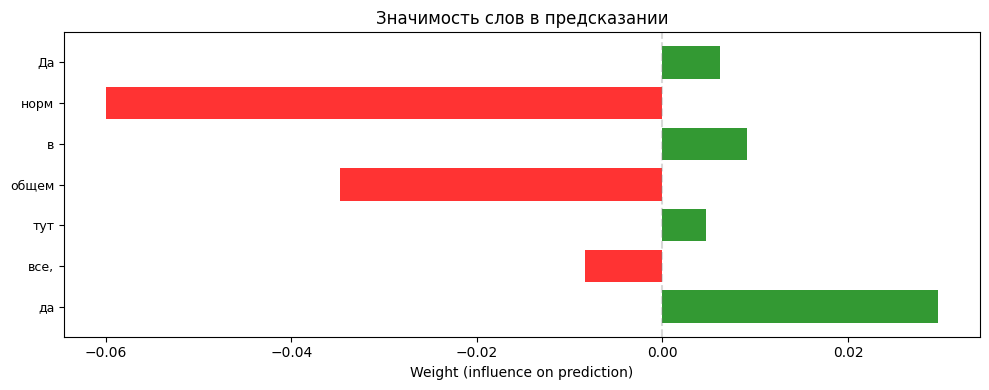

In [57]:
# --- Использование ---
predict_fn = create_lime_predictor(model, tokenizer, device, MAX_LENGTH)
class_names = ['Negative', 'Positive']
explainer = LimeTextExplainer(class_names=class_names)

text = "Да норм в общем тут все, да"
explanation = explainer.explain_instance(text, predict_fn, num_samples=1000, top_labels=2)

# Результаты
print(f"Probabilities: Neg={explanation.predict_proba[0]:.3f}, Pos={explanation.predict_proba[1]:.3f}")
print(f"Predicted: {class_names[np.argmax(explanation.predict_proba[0])]}")
plot_lime_explanation_original_order(explanation, text)

---

### Перевод модели в ONNX

In [64]:
# Создаем обертку для модели, которая добавляет reshape
class ModelWithReshape(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.original_model = original_model

    def forward(self, input_ids, attention_mask):
        output = self.original_model(input_ids, attention_mask)
        # Добавляем размерность: [batch] -> [batch, 1]
        output = output.unsqueeze(-1)
        return output

# Конвертация с оберткой
def convert_to_onnx(model, tokenizer, device, output_path="model.onnx", max_length=64):
    model.eval()

    # Оборачиваем модель
    wrapped_model = ModelWithReshape(model)
    wrapped_model.eval()

    dummy_text = "dummy text for onnx export"
    dummy_inputs = tokenizer(dummy_text, truncation=True, padding='max_length',
                            max_length=max_length, return_tensors='pt')

    dummy_input_ids = dummy_inputs['input_ids'].to(device)
    dummy_attention_mask = dummy_inputs['attention_mask'].to(device)

    # Экспортируем обернутую модель
    torch.onnx.export(
        wrapped_model,
        (dummy_input_ids, dummy_attention_mask),
        output_path,
        input_names=['input_ids', 'attention_mask'],
        output_names=['output'],
        dynamic_axes={
            'input_ids': {0: 'batch_size'},
            'attention_mask': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        },
        opset_version=14
    )

    print(f"Модель с выходом размерности [batch, 1] сохранена в {output_path}")

# Сохраняем модель
convert_to_onnx(model, tokenizer, device, "model.onnx", MAX_LENGTH)

W0722 18:17:55.259000 694 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ModelWithReshape([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ModelWithReshape([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /project/onnx/version_converter/adapters/no_previous_version.h:24: adapt: Assertion `false` fa

[torch.onnx] Optimize the ONNX graph...


[torch.onnx] Optimize the ONNX graph... ✅
Модель с выходом размерности [batch, 1] сохранена в model.onnx
